In [1]:
import os
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
# =========================
# CONFIG
# =========================

BASE_DIR = Path("/data/shared/fsibilla/clean_code/Q1/bayesian")

# Put here the experiments you want to compare
EXPERIMENTS = [
    "eth_micron",
    "lka_micron",
    "lka_vam",
    "moz_vam",
    "nga_micron",
    "nga_mics",
    "yem_mvam",
    "zwe_mics"
]

RESULT_FILENAME = "eval_adm1.csv"

# Optional: restrict to a subset of variables
VARIABLES_TO_KEEP = None
# example:
# VARIABLES_TO_KEEP = ["wscore", "space_per_person", "avg_adult_education"]

In [3]:
def norm_place(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.replace("’","'").replace("‘","'").replace("`","'")
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    s = s.replace("'", "")
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\bgovernorate\b", "", s).strip()
    return s


def safe_mean(x):
    x = pd.Series(x).astype(float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    return float(x.mean())


def safe_sd(x, ddof=0):
    x = pd.Series(x).astype(float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    return float(x.std(ddof=ddof))


def standardized_abs_error(true_value, pred_value, sd_ref):
    """
    |pred - true| / sd_ref
    """
    if not np.isfinite(true_value) or not np.isfinite(pred_value) or not np.isfinite(sd_ref) or sd_ref == 0:
        return np.nan
    return float(abs(pred_value - true_value) / sd_ref)

In [4]:
all_tables = []

for exp_name in EXPERIMENTS:
    fp = BASE_DIR / exp_name / RESULT_FILENAME
    
    if not fp.exists():
        print(f"[WARNING] Missing file for experiment '{exp_name}': {fp}")
        continue

    df = pd.read_csv(fp)
    df["experiment"] = exp_name
    
    # normalize ADM1 name just in case
    if "adm1" in df.columns:
        df["adm1_norm"] = df["adm1"].map(norm_place)
    else:
        raise ValueError(f"'adm1' column not found in {fp}")

    all_tables.append(df)

if not all_tables:
    raise ValueError("No result tables were loaded. Check BASE_DIR and EXPERIMENTS.")

results_all = pd.concat(all_tables, ignore_index=True)

if VARIABLES_TO_KEEP is not None:
    results_all = results_all[results_all["variable"].isin(VARIABLES_TO_KEEP)].copy()

print(f"Loaded rows: {len(results_all):,}")
print(f"Experiments loaded: {results_all['experiment'].nunique()}")
print(f"Variables: {results_all['variable'].nunique()}")
print(f"ADM1 units: {results_all['adm1_norm'].nunique()}")

results_all.head()

Loaded rows: 715
Experiments loaded: 8
Variables: 23
ADM1 units: 100


,adm1,variable,true_mean,gen_mean,gen_std,gen_mean_between_seed_sd,n_seeds,bayes_mean,bayes_std,bayes_mean_between_seed_sd,n_seeds_bayes,gen_abs_err,bayes_abs_err,gen_sq_err,bayes_sq_err,delta_abs_err,winner_abs,experiment,adm1_norm
0,Addis Ababa,avg_adult_education,12.336833,12.760252,0.861341,1.677205,5,12.150581,1.109721,2.469583,5,0.423418,0.186253,0.179283,0.034690,0.237166,Bayesian MVN,eth_micron,addis ababa
1,Addis Ababa,fe_ai,29.319499,29.450531,4.908192,10.622815,5,37.237903,7.103853,15.868578,5,0.131032,7.918404,0.017169,62.701122,-7.787372,RealNVP,eth_micron,addis ababa
2,Addis Ababa,fol_ai,290.654229,320.704579,51.852998,113.127171,5,318.957264,88.208892,196.948114,5,30.050350,28.303034,903.023522,801.061745,1.747316,Bayesian MVN,eth_micron,addis ababa
3,Addis Ababa,log_exp,7.018489,7.154453,0.208630,0.428185,5,7.051668,0.532352,1.189605,5,0.135964,0.033178,0.018486,0.001101,0.102786,Bayesian MVN,eth_micron,addis ababa
4,Addis Ababa,va_ai,398.217953,382.082750,84.462057,183.887539,5,408.262777,85.450582,190.409135,5,16.135203,10.044824,260.344777,100.898490,6.090379,Bayesian MVN,eth_micron,addis ababa


In [5]:
# SD of true ADM1 means, by experiment and variable
true_sd_by_exp_var = (
    results_all
    .groupby(["experiment", "variable"], as_index=False)["true_mean"]
    .std(ddof=0)
    .rename(columns={"true_mean": "sd_true_across_adm1"})
)

results_eval = results_all.merge(
    true_sd_by_exp_var,
    on=["experiment", "variable"],
    how="left"
)

results_eval["gen_abs_err_std"] = results_eval.apply(
    lambda r: standardized_abs_error(r["true_mean"], r["gen_mean"], r["sd_true_across_adm1"]),
    axis=1
)

results_eval["bayes_abs_err_std"] = results_eval.apply(
    lambda r: standardized_abs_error(r["true_mean"], r["bayes_mean"], r["sd_true_across_adm1"]),
    axis=1
)

results_eval["delta_abs_err_std"] = (
    results_eval["gen_abs_err_std"] - results_eval["bayes_abs_err_std"]
)

results_eval["winner_abs_std"] = np.where(
    results_eval["bayes_abs_err_std"] < results_eval["gen_abs_err_std"],
    "Bayesian MVN",
    np.where(
        results_eval["bayes_abs_err_std"] > results_eval["gen_abs_err_std"],
        "Generated",
        "Tie"
    )
)

results_eval.head()

,adm1,variable,true_mean,gen_mean,gen_std,gen_mean_between_seed_sd,n_seeds,bayes_mean,bayes_std,bayes_mean_between_seed_sd,...,bayes_sq_err,delta_abs_err,winner_abs,experiment,adm1_norm,sd_true_across_adm1,gen_abs_err_std,bayes_abs_err_std,delta_abs_err_std,winner_abs_std
0,Addis Ababa,avg_adult_education,12.336833,12.760252,0.861341,1.677205,5,12.150581,1.109721,2.469583,...,0.034690,0.237166,Bayesian MVN,eth_micron,addis ababa,2.722030,0.155552,0.068424,0.087128,Bayesian MVN
1,Addis Ababa,fe_ai,29.319499,29.450531,4.908192,10.622815,5,37.237903,7.103853,15.868578,...,62.701122,-7.787372,RealNVP,eth_micron,addis ababa,8.514303,0.015390,0.930012,-0.914622,Generated
2,Addis Ababa,fol_ai,290.654229,320.704579,51.852998,113.127171,5,318.957264,88.208892,196.948114,...,801.061745,1.747316,Bayesian MVN,eth_micron,addis ababa,91.135927,0.329731,0.310558,0.019173,Bayesian MVN
3,Addis Ababa,log_exp,7.018489,7.154453,0.208630,0.428185,5,7.051668,0.532352,1.189605,...,0.001101,0.102786,Bayesian MVN,eth_micron,addis ababa,0.656021,0.207255,0.050575,0.156680,Bayesian MVN
4,Addis Ababa,va_ai,398.217953,382.082750,84.462057,183.887539,5,408.262777,85.450582,190.409135,...,100.898490,6.090379,Bayesian MVN,eth_micron,addis ababa,146.891775,0.109844,0.068382,0.041462,Bayesian MVN


In [6]:
overall_eval = pd.DataFrame({
    "n_rows": [len(results_eval)],
    "n_experiments": [results_eval["experiment"].nunique()],
    "n_variables": [results_eval["variable"].nunique()],
    "n_adm1": [results_eval["adm1_norm"].nunique()],
    
    "gen_abs_err_raw_mean": [safe_mean(results_eval["gen_abs_err"]) if "gen_abs_err" in results_eval.columns else np.nan],
    "bayes_abs_err_raw_mean": [safe_mean(results_eval["bayes_abs_err"]) if "bayes_abs_err" in results_eval.columns else np.nan],
    
    "gen_abs_err_std_mean": [safe_mean(results_eval["gen_abs_err_std"])],
    "bayes_abs_err_std_mean": [safe_mean(results_eval["bayes_abs_err_std"])],
    
    "gen_abs_err_std_median": [results_eval["gen_abs_err_std"].median()],
    "bayes_abs_err_std_median": [results_eval["bayes_abs_err_std"].median()],
    
    "mean_delta_abs_err_std_gen_minus_bayes": [safe_mean(results_eval["delta_abs_err_std"])],
    
    "bayes_win_rate": [(results_eval["winner_abs_std"] == "Bayesian MVN").mean()],
    "generated_win_rate": [(results_eval["winner_abs_std"] == "Generated").mean()],
    "tie_rate": [(results_eval["winner_abs_std"] == "Tie").mean()],
})

overall_eval.T

,0
n_rows,715.000000
n_experiments,8.000000
n_variables,23.000000
n_adm1,100.000000
gen_abs_err_raw_mean,8.008982
bayes_abs_err_raw_mean,8.754629
gen_abs_err_std_mean,0.616106
bayes_abs_err_std_mean,0.708716
gen_abs_err_std_median,0.468109
bayes_abs_err_std_median,0.522574


In [7]:
by_variable_eval = (
    results_eval
    .groupby("variable", as_index=False)
    .agg(
        n_obs=("variable", "size"),
        sd_true_across_adm1=("sd_true_across_adm1", "mean"),
        
        gen_abs_err_std_mean=("gen_abs_err_std", "mean"),
        bayes_abs_err_std_mean=("bayes_abs_err_std", "mean"),
        
        gen_abs_err_std_median=("gen_abs_err_std", "median"),
        bayes_abs_err_std_median=("bayes_abs_err_std", "median"),
        
        delta_abs_err_std_mean=("delta_abs_err_std", "mean"),
        bayes_win_rate=("winner_abs_std", lambda x: (x == "Bayesian MVN").mean()),
        generated_win_rate=("winner_abs_std", lambda x: (x == "Generated").mean()),
        tie_rate=("winner_abs_std", lambda x: (x == "Tie").mean()),
    )
    .sort_values("delta_abs_err_std_mean")
    .reset_index(drop=True)
)

by_variable_eval

,variable,n_obs,sd_true_across_adm1,gen_abs_err_std_mean,bayes_abs_err_std_mean,gen_abs_err_std_median,bayes_abs_err_std_median,delta_abs_err_std_mean,bayes_win_rate,generated_win_rate,tie_rate
0,zn_mg,9,0.500377,0.677630,1.866170,0.627773,1.222951,-1.188540,0.111111,0.888889,0.0
1,fe_mg,9,1.403883,0.506200,1.014289,0.258284,1.109036,-0.508089,0.333333,0.666667,0.0
2,vita_rae_mcg,9,26.819249,1.000233,1.481850,0.653546,1.418983,-0.481617,0.444444,0.555556,0.0
3,FGProtein,11,0.882505,0.917491,1.076553,0.851896,1.453262,-0.159062,0.454545,0.545455,0.0
4,FGHIron,11,0.440326,0.667278,0.817174,0.653381,0.542801,-0.149895,0.454545,0.545455,0.0
5,vitb12_mcg,9,0.316810,0.655693,0.777135,0.755535,0.628663,-0.121443,0.333333,0.666667,0.0
6,FES,9,0.022552,0.904001,1.016380,1.035706,0.563639,-0.112379,0.444444,0.555556,0.0
7,log_exp,57,0.455219,0.576052,0.688161,0.417674,0.393570,-0.112109,0.473684,0.526316,0.0
8,fe_ai,48,4.099423,0.685821,0.787301,0.570778,0.666005,-0.101480,0.333333,0.666667,0.0
9,rCSI,42,2.075864,0.683156,0.779971,0.491017,0.501720,-0.096815,0.404762,0.595238,0.0


In [8]:
scatter_df = (
    results_eval
    .groupby(["experiment", "variable"], as_index=False)
    .agg(
        bayes_err_mean=("bayes_abs_err_std", "mean"),
        bayes_err_sd=("bayes_abs_err_std", "std"),
        gen_err_mean=("gen_abs_err_std", "mean"),
        gen_err_sd=("gen_abs_err_std", "std"),
        n=("adm1_norm", "size"),
    )
)

scatter_df["label"] = scatter_df["experiment"].astype(str) + " | " + scatter_df["variable"].astype(str)

scatter_df.head()

,experiment,variable,bayes_err_mean,bayes_err_sd,gen_err_mean,gen_err_sd,n,label
0,eth_micron,avg_adult_education,0.329804,0.305609,0.539526,0.430796,11,eth_micron | avg_adult_education
1,eth_micron,fe_ai,0.846693,0.471925,0.652508,0.631060,11,eth_micron | fe_ai
2,eth_micron,fol_ai,0.673792,0.436884,0.537900,0.436119,11,eth_micron | fol_ai
3,eth_micron,log_exp,0.186946,0.209773,0.512098,0.471713,11,eth_micron | log_exp
4,eth_micron,va_ai,0.708462,0.832695,0.564123,0.620264,11,eth_micron | va_ai


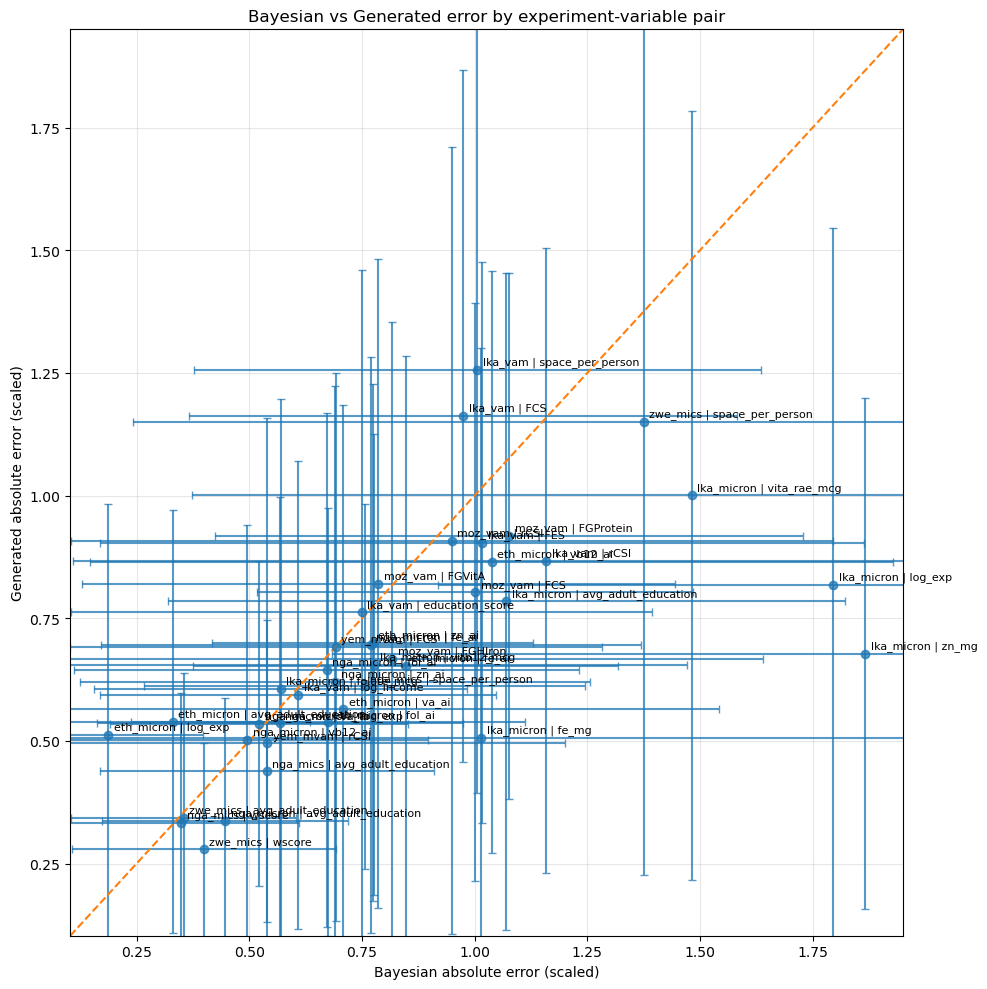

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = scatter_df.dropna(subset=["bayes_err_mean", "gen_err_mean"]).copy()

fig, ax = plt.subplots(figsize=(10, 10))

ax.errorbar(
    plot_df["bayes_err_mean"],
    plot_df["gen_err_mean"],
    xerr=plot_df["bayes_err_sd"],
    yerr=plot_df["gen_err_sd"],
    fmt="o",
    capsize=3,
    alpha=0.75
)

for _, r in plot_df.iterrows():
    ax.annotate(
        r["label"],
        (r["bayes_err_mean"], r["gen_err_mean"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

all_vals = np.concatenate([
    plot_df["bayes_err_mean"].values,
    plot_df["gen_err_mean"].values
])

vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)
pad = 0.05 * (vmax - vmin) if vmax > vmin else 0.1

line_min = max(0, vmin - pad)
line_max = vmax + pad

ax.plot([line_min, line_max], [line_min, line_max], linestyle="--")

ax.set_xlim(line_min, line_max)
ax.set_ylim(line_min, line_max)

ax.set_xlabel("Bayesian absolute error (scaled)")
ax.set_ylabel("Generated absolute error (scaled)")
ax.set_title("Bayesian vs Generated error by experiment-variable pair")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
df = pd.read_csv('/data/shared/fsibilla/clean_code/Q1/bayesian/lka_vam/results/seed_1/rnvp_generated_run0.csv')

In [11]:
max(df['rCSI'])

36.97816610336304

In [23]:
scatter_df.head()

,experiment,variable,bayes_err_mean,bayes_err_sd,gen_err_mean,gen_err_sd,n,label
0,eth_micron,avg_adult_education,0.329804,0.305609,0.539526,0.430796,11,eth_micron | avg_adult_education
1,eth_micron,fe_ai,0.846693,0.471925,0.652508,0.631060,11,eth_micron | fe_ai
2,eth_micron,fol_ai,0.673792,0.436884,0.537900,0.436119,11,eth_micron | fol_ai
3,eth_micron,log_exp,0.186946,0.209773,0.512098,0.471713,11,eth_micron | log_exp
4,eth_micron,va_ai,0.708462,0.832695,0.564123,0.620264,11,eth_micron | va_ai


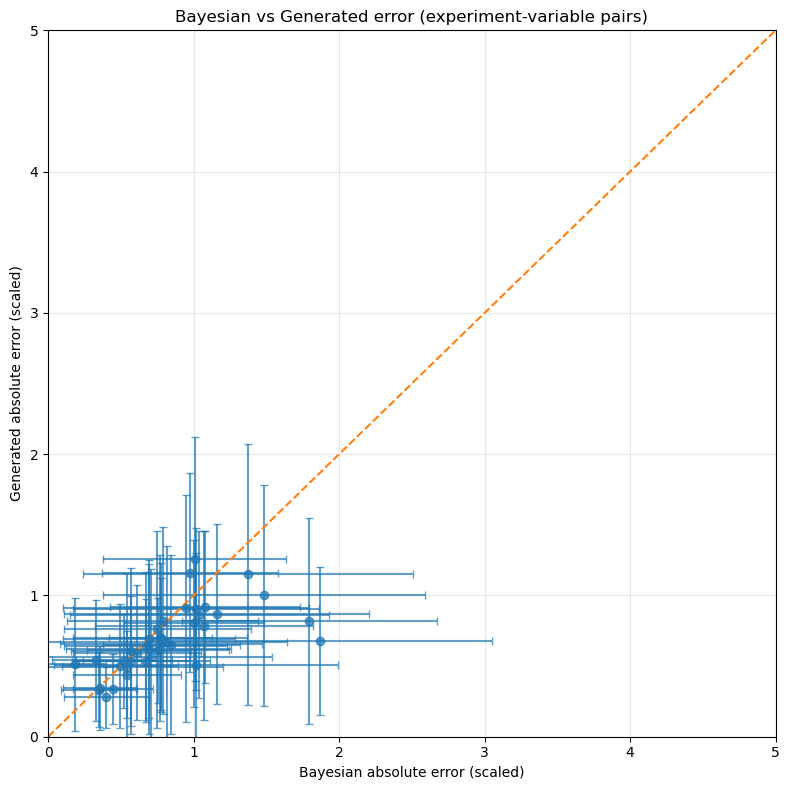

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = scatter_df.dropna(subset=["bayes_err_mean", "gen_err_mean"]).copy()

fig, ax = plt.subplots(figsize=(8, 8))

ax.errorbar(
    plot_df["bayes_err_mean"],
    plot_df["gen_err_mean"],
    xerr=plot_df["bayes_err_sd"],
    yerr=plot_df["gen_err_sd"],
    fmt="o",
    capsize=3,
    alpha=0.7
)

# diagonal y = x
ax.plot([0, 50], [0, 50], linestyle="--")

# fixed limits
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

ax.set_xlabel("Bayesian absolute error (scaled)")
ax.set_ylabel("Generated absolute error (scaled)")
ax.set_title("Bayesian vs Generated error (experiment-variable pairs)")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

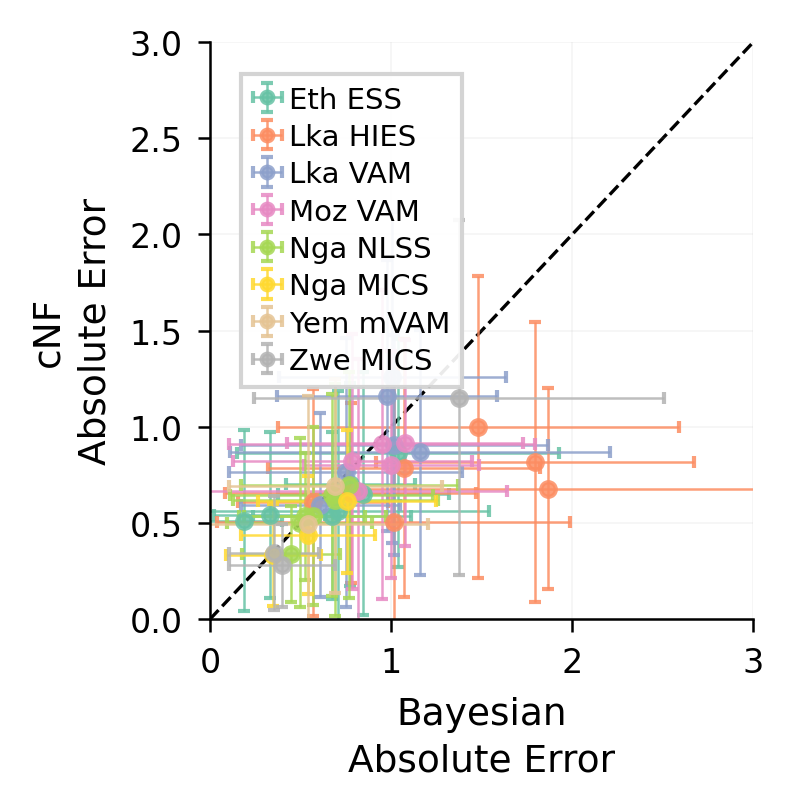

In [26]:
from cycler import cycler
import matplotlib.pyplot as plt
import numpy as np

EXPERIMENT_LABELS = {
    "eth_micron": "Eth ESS",
    "lka_micron": "Lka HIES",
    "lka_vam":    "Lka VAM",
    "moz_vam":    "Moz VAM",
    "nga_micron": "Nga NLSS",
    "nga_mics":   "Nga MICS",
    "yem_mvam":   "Yem mVAM",
    "zwe_mics":   "Zwe MICS",
}

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": cycler("color", plt.get_cmap("Set2").colors),
})

plot_df = scatter_df.dropna(subset=["bayes_err_mean", "gen_err_mean"]).copy()

fig, ax = plt.subplots(figsize=(2.8, 2.8), dpi=300)

lo, hi = 0, 3
ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=0.8, zorder=1)

for exp_id in sorted(plot_df["experiment"].unique()):
    d = plot_df[plot_df["experiment"] == exp_id]
    ax.errorbar(
        d["bayes_err_mean"], d["gen_err_mean"],
        xerr=d["bayes_err_sd"], yerr=d["gen_err_sd"],
        fmt="o", linestyle="none",
        markersize=3.5, alpha=0.85,
        elinewidth=0.6, capsize=1.5,
        zorder=2,
        label=EXPERIMENT_LABELS.get(exp_id, exp_id),
    )

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Bayesian\nAbsolute Error", linespacing=1.4)
ax.set_ylabel("cNF\nAbsolute Error", linespacing=1.4)
ax.grid(True, alpha=0.12, linewidth=0.4)

ax.legend(
    loc="upper left", bbox_to_anchor=(0.03, 0.97),
    ncol=1, frameon=True, framealpha=0.92, edgecolor="0.82", fancybox=False,
    fontsize=7, handlelength=1.0, handletextpad=0.25, labelspacing=0.32,
    borderpad=0.4, markerscale=0.8,
)

fig.tight_layout(pad=1.2)
plt.savefig("/data/shared/fsibilla/clean_code/Q1/bayesian/comp.pdf", bbox_inches="tight")

plt.show()

## is there difference?

In [13]:
import numpy as np
import pandas as pd

ADM1_PLOT_COL = "adm1"   # change to "adm1_norm" if needed

plot_base = results_eval.copy()

# keep only rows where both methods are available
plot_base = plot_base.dropna(subset=["bayes_abs_err_std", "gen_abs_err_std"]).copy()

# unique tuple id
plot_base["tuple_id"] = (
    plot_base["experiment"].astype(str) + " | " +
    plot_base[ADM1_PLOT_COL].astype(str) + " | " +
    plot_base["variable"].astype(str)
)

# long format for violin plot
violins_df = pd.concat([
    plot_base[["tuple_id", "experiment", ADM1_PLOT_COL, "variable", "bayes_abs_err_std"]]
        .rename(columns={"bayes_abs_err_std": "error"})
        .assign(method="Bayesian"),
    plot_base[["tuple_id", "experiment", ADM1_PLOT_COL, "variable", "gen_abs_err_std"]]
        .rename(columns={"gen_abs_err_std": "error"})
        .assign(method="Generated")
], ignore_index=True)

print("Number of paired tuples:", plot_base["tuple_id"].nunique())
violins_df.head()

Number of paired tuples: 693


,tuple_id,experiment,adm1,variable,error,method
0,eth_micron | Addis Ababa | avg_adult_education,eth_micron,Addis Ababa,avg_adult_education,0.068424,Bayesian
1,eth_micron | Addis Ababa | fe_ai,eth_micron,Addis Ababa,fe_ai,0.930012,Bayesian
2,eth_micron | Addis Ababa | fol_ai,eth_micron,Addis Ababa,fol_ai,0.310558,Bayesian
3,eth_micron | Addis Ababa | log_exp,eth_micron,Addis Ababa,log_exp,0.050575,Bayesian
4,eth_micron | Addis Ababa | va_ai,eth_micron,Addis Ababa,va_ai,0.068382,Bayesian


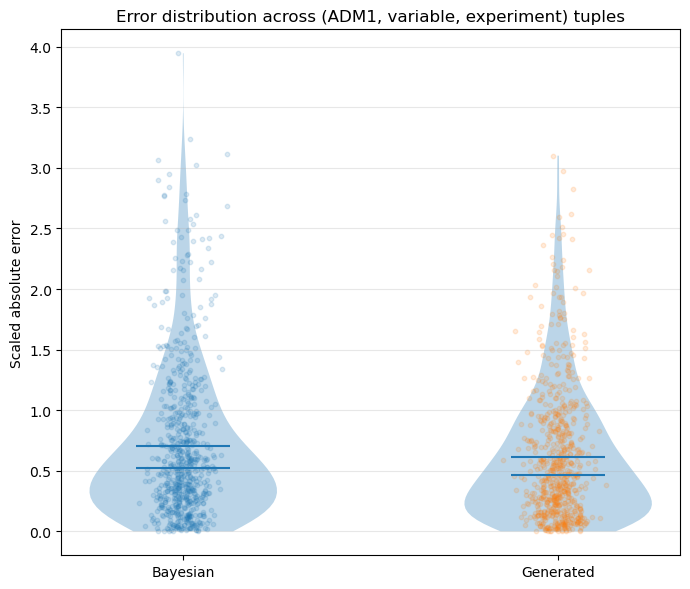

In [14]:
import matplotlib.pyplot as plt
import numpy as np

bayes_plot = violins_df.loc[violins_df["method"] == "Bayesian", "error"].dropna().values
gen_plot   = violins_df.loc[violins_df["method"] == "Generated", "error"].dropna().values

fig, ax = plt.subplots(figsize=(7, 6))

ax.violinplot(
    [bayes_plot, gen_plot],
    positions=[1, 2],
    showmeans=True,
    showmedians=True,
    showextrema=False
)

# jittered raw points
rng = np.random.default_rng(42)
x1 = 1 + rng.normal(0, 0.04, size=len(bayes_plot))
x2 = 2 + rng.normal(0, 0.04, size=len(gen_plot))

ax.scatter(x1, bayes_plot, alpha=0.15, s=10)
ax.scatter(x2, gen_plot, alpha=0.15, s=10)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Bayesian", "Generated"])
ax.set_ylabel("Scaled absolute error")
ax.set_title("Error distribution across (ADM1, variable, experiment) tuples")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
violins_df.head()

,tuple_id,experiment,adm1,variable,error,method
0,eth_micron | Addis Ababa | avg_adult_education,eth_micron,Addis Ababa,avg_adult_education,0.068424,Bayesian
1,eth_micron | Addis Ababa | fe_ai,eth_micron,Addis Ababa,fe_ai,0.930012,Bayesian
2,eth_micron | Addis Ababa | fol_ai,eth_micron,Addis Ababa,fol_ai,0.310558,Bayesian
3,eth_micron | Addis Ababa | log_exp,eth_micron,Addis Ababa,log_exp,0.050575,Bayesian
4,eth_micron | Addis Ababa | va_ai,eth_micron,Addis Ababa,va_ai,0.068382,Bayesian


In [16]:
# Aggregate to (experiment, variable) level — mean error per ADM1 group
agg_df = (
    violins_df
    .groupby(["experiment", "variable", "method"], as_index=False)["error"]
    .mean()
)

# Sort to guarantee alignment before pairing
agg_df = agg_df.sort_values(["experiment", "variable", "method"]).reset_index(drop=True)

bayes_vals = agg_df.loc[agg_df["method"] == "Bayesian"].sort_values(["experiment", "variable"])["error"].values
gen_vals   = agg_df.loc[agg_df["method"] == "Generated"].sort_values(["experiment", "variable"])["error"].values

print(f"N pairs after aggregation: {len(bayes_vals)}")
assert len(bayes_vals) == len(gen_vals), "Mismatch in number of pairs — check for missing method entries"
agg_df.head(10)

N pairs after aggregation: 40


,experiment,variable,method,error
0,eth_micron,avg_adult_education,Bayesian,0.329804
1,eth_micron,avg_adult_education,Generated,0.539526
2,eth_micron,fe_ai,Bayesian,0.846693
3,eth_micron,fe_ai,Generated,0.652508
4,eth_micron,fol_ai,Bayesian,0.673792
5,eth_micron,fol_ai,Generated,0.537900
6,eth_micron,log_exp,Bayesian,0.186946
7,eth_micron,log_exp,Generated,0.512098
8,eth_micron,va_ai,Bayesian,0.708462
9,eth_micron,va_ai,Generated,0.564123


Paired t-test: t = 2.954, p = 0.0053 (n=40 pairs)


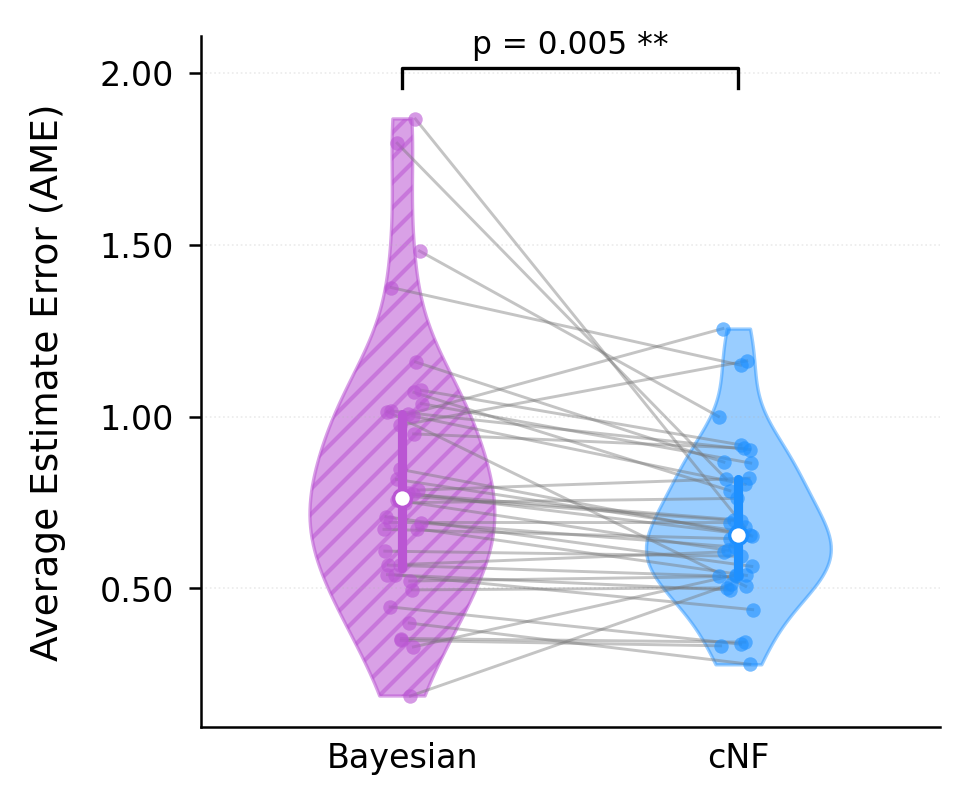

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy import stats

# ── rcParams (matching your style) ─────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         300,
    "svg.fonttype":       "none",
})

C_BAYES = 'mediumorchid'
C_GEN   = 'DodgerBlue'

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy import stats

# ── Paired t-test ───────────────────────────────────────────────────────────
n = len(bayes_vals)
t_stat, p_val = stats.ttest_rel(bayes_vals, gen_vals)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f} (n={n} pairs)")

if p_val < 0.001:
    sig_label = "p < 0.001 ***"
elif p_val < 0.01:
    sig_label = f"p = {p_val:.3f} **"
elif p_val < 0.05:
    sig_label = f"p = {p_val:.3f} *"
else:
    sig_label = f"p = {p_val:.3f} (n.s.)"

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.2, 3.2))
fig.subplots_adjust(left=0.18, right=0.95, top=0.90, bottom=0.18)

rng = np.random.default_rng(42)

xs      = [0.0, 1.0]
colors  = [C_BAYES, C_GEN]
alphas  = [0.55, 0.45]
hatches = ["////",None]
vals_list = [bayes_vals, gen_vals]
labels  = ["Bayesian", "cNF"]

for x, vals, color, alpha, hatch in zip(xs, vals_list, colors, alphas, hatches):
    parts = ax.violinplot(
        vals, positions=[x], widths=0.55,
        showmedians=False, showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(alpha)
        pc.set_linewidth(0.8)
        if hatch:
            pc.set_hatch(hatch)

    q25, med, q75 = np.percentile(vals, [25, 50, 75])
    ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
            solid_capstyle="round", zorder=5)
    ax.scatter(x, med, color="white", s=18, zorder=6,
               linewidths=0.8, edgecolors=color)

# paired lines + points
j1 = rng.uniform(-0.06, 0.06, size=n)
j2 = rng.uniform(-0.06, 0.06, size=n)
x1 = xs[0] + j1
x2 = xs[1] + j2

for i in range(n):
    ax.plot([x1[i], x2[i]], [bayes_vals[i], gen_vals[i]],
            color="0.45", linewidth=0.7, alpha=0.42, zorder=2)

ax.scatter(x1, bayes_vals, color=C_BAYES, s=12, alpha=0.6, linewidths=0, zorder=3)
ax.scatter(x2, gen_vals,   color=C_GEN,   s=12, alpha=0.6, linewidths=0, zorder=3)

# significance bracket
y_top = max(bayes_vals.max(), gen_vals.max())
y_bracket = y_top * 1.08
ax.plot([0, 0, 1, 1], [y_bracket*0.97, y_bracket, y_bracket, y_bracket*0.97],
        color="black", linewidth=0.8)
ax.text(0.5, y_bracket * 1.01, sig_label, ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_ylabel("Average Estimate Error (AME)", fontsize=9, labelpad=8)

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
ax.set_xlim(-0.6, 1.6)
ax.tick_params(axis="x", length=0)

fig.savefig("violin_bayesian_vs_generated.svg", bbox_inches="tight")
fig.savefig("violin_bayesian_vs_generated.png", bbox_inches="tight", dpi=300)
plt.show()

Paired t-test: t = 2.954, p = 0.0053 (n=40 pairs)


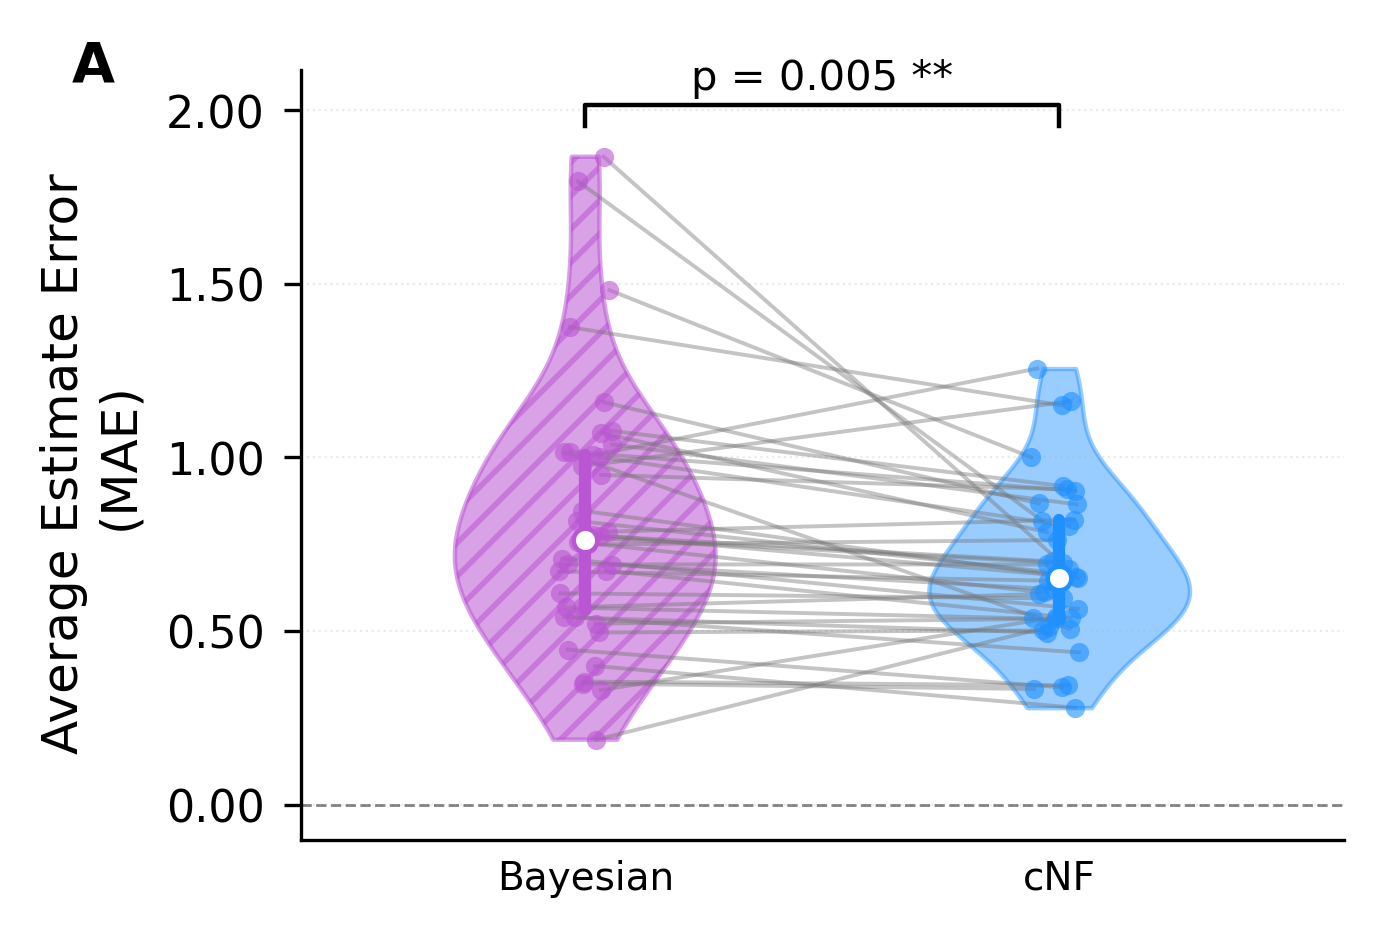

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy import stats

# ── Style — identical to other violin figure ─────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     7,
    "axes.labelweight":   "normal",
    "axes.titlesize":     7,
    "xtick.labelsize":    7,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         400,
    "svg.fonttype":       "none",
})

C_BAYES = 'mediumorchid'
C_GEN   = 'DodgerBlue'

# ── Paired t-test ─────────────────────────────────────────────────────────────
n = len(bayes_vals)
t_stat, p_val = stats.ttest_rel(bayes_vals, gen_vals)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f} (n={n} pairs)")

if p_val < 0.001:
    sig_label = "p < 0.001 ***"
elif p_val < 0.01:
    sig_label = f"p = {p_val:.3f} **"
elif p_val < 0.05:
    sig_label = f"p = {p_val:.3f} *"
else:
    sig_label = f"p = {p_val:.3f} (n.s.)"

# ── Figure — same width as other violin, single panel height ─────────────────
fig, ax = plt.subplots(figsize=(3.3, 2.6))
fig.subplots_adjust(left=0.18, right=0.97, top=0.88, bottom=0.14)

rng     = np.random.default_rng(42)
xs      = [0.0, 1.0]
colors  = [C_BAYES, C_GEN]
alphas  = [0.55, 0.45]
hatches = ["////", None]
vals_list = [bayes_vals, gen_vals]
labels    = ["Bayesian", "cNF"]

for x, vals, color, alpha, hatch in zip(xs, vals_list, colors, alphas, hatches):
    parts = ax.violinplot(
        vals, positions=[x], widths=0.55,
        showmedians=False, showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(alpha)
        pc.set_linewidth(0.8)
        if hatch:
            pc.set_hatch(hatch)

    q25, med, q75 = np.percentile(vals, [25, 50, 75])
    ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
            solid_capstyle="round", zorder=5)
    ax.scatter(x, med, color="white", s=18, zorder=6,
               linewidths=0.8, edgecolors=color)

# paired lines + points
j1 = rng.uniform(-0.06, 0.06, size=n)
j2 = rng.uniform(-0.06, 0.06, size=n)
x1 = xs[0] + j1
x2 = xs[1] + j2

for i in range(n):
    ax.plot([x1[i], x2[i]], [bayes_vals[i], gen_vals[i]],
            color="0.45", linewidth=0.7, alpha=0.42, zorder=2)

ax.scatter(x1, bayes_vals, color=C_BAYES, s=12, alpha=0.6, linewidths=0, zorder=3)
ax.scatter(x2, gen_vals,   color=C_GEN,   s=12, alpha=0.6, linewidths=0, zorder=3)

ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

# significance bracket
y_top     = max(bayes_vals.max(), gen_vals.max())
y_bracket = y_top * 1.08
ax.plot([0, 0, 1, 1],
        [y_bracket * 0.97, y_bracket, y_bracket, y_bracket * 0.97],
        color="black", linewidth=0.8)
ax.text(0.5, y_bracket * 1.01, sig_label,
        ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_ylabel("Average Estimate Error \n(MAE)", fontsize=9, labelpad=4)

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
ax.set_xlim(-0.6, 1.6)
ax.tick_params(axis="x", length=0)

# panel letter
ax.text(
    -0.22, 1.04, "A",
    transform=ax.transAxes,
    fontsize=10, fontweight="bold",
    va="top", ha="left"
)

# ── Save ─────────────────────────────────────────────────────────────────────
fig.savefig("violin_bayesian_vs_generated.png", bbox_inches="tight", dpi=400)
fig.savefig("violin_bayesian_vs_generated.pdf", bbox_inches="tight")
fig.savefig("violin_bayesian_vs_generated.svg", bbox_inches="tight")
plt.show()

In [19]:
from scipy.stats import wilcoxon, ttest_rel

paired_df = plot_base[[
    "tuple_id",
    "bayes_abs_err_std",
    "gen_abs_err_std"
]].dropna().copy()

paired_df["diff_gen_minus_bayes"] = (
    paired_df["gen_abs_err_std"] - paired_df["bayes_abs_err_std"]
)

print("Number of paired observations:", len(paired_df))

# Wilcoxon signed-rank test
wilcox_res = wilcoxon(
    paired_df["gen_abs_err_std"],
    paired_df["bayes_abs_err_std"],
    alternative="two-sided",
    zero_method="wilcox"
)

# paired t-test (secondary / optional)
ttest_res = ttest_rel(
    paired_df["gen_abs_err_std"],
    paired_df["bayes_abs_err_std"],
    nan_policy="omit"
)

summary_stats = pd.DataFrame({
    "metric": [
        "n_pairs",
        "bayes_mean",
        "gen_mean",
        "bayes_median",
        "gen_median",
        "mean_diff_gen_minus_bayes",
        "median_diff_gen_minus_bayes",
        "wilcoxon_stat",
        "wilcoxon_pvalue",
        "paired_t_stat",
        "paired_t_pvalue",
    ],
    "value": [
        len(paired_df),
        paired_df["bayes_abs_err_std"].mean(),
        paired_df["gen_abs_err_std"].mean(),
        paired_df["bayes_abs_err_std"].median(),
        paired_df["gen_abs_err_std"].median(),
        paired_df["diff_gen_minus_bayes"].mean(),
        paired_df["diff_gen_minus_bayes"].median(),
        wilcox_res.statistic,
        wilcox_res.pvalue,
        ttest_res.statistic,
        ttest_res.pvalue,
    ]
})

summary_stats

Number of paired observations: 693


,metric,value
0,n_pairs,693.000000
1,bayes_mean,0.708716
2,gen_mean,0.616106
3,bayes_median,0.522574
4,gen_median,0.468109
5,mean_diff_gen_minus_bayes,-0.092611
6,median_diff_gen_minus_bayes,-0.048394
7,wilcoxon_stat,97500.000000
8,wilcoxon_pvalue,0.000016
9,paired_t_stat,-4.853649


In [20]:
diff = paired_df["diff_gen_minus_bayes"].dropna().values

effect_summary = pd.DataFrame({
    "metric": [
        "mean_diff_gen_minus_bayes",
        "median_diff_gen_minus_bayes",
        "pct_bayes_better",
        "pct_gen_better",
        "pct_tie"
    ],
    "value": [
        np.mean(diff),
        np.median(diff),
        np.mean(diff > 0),   # Gen error > Bayes error => Bayes better
        np.mean(diff < 0),   # Gen better
        np.mean(diff == 0)
    ]
})

effect_summary

,metric,value
0,mean_diff_gen_minus_bayes,-0.092611
1,median_diff_gen_minus_bayes,-0.048394
2,pct_bayes_better,0.428571
3,pct_gen_better,0.571429
4,pct_tie,0.000000
